# Dimensionality Reduction

**Sentence Summary:** 

Dimensionality reduction in linear algebra is the process of reducing the number of variables and condensing the dataset into fewer dimensions while retaining as much of the original information as possible, preserving the core characteristics of the data.

**Paragraph Summary**:

Dimensionality reduction in linear algebra is a technique used to simplify complex datasets by reducing the number of variables while preserving the essential characteristics of the original data. This process is crucial for enhancing the efficiency and effectiveness of data analysis in STEM, particularly in machine learning and data science. By condensing high dimensional data into a lower dimensional space, dimensionality reduction facilitates improved computational efficiency, and the interpretability of the dataset through the reduction of noise and irrelevant variables present in a dataset.

## The General Idea

Suppose we have some matrix $A$. This matrix could be formed from some dataset, system of equations, or from a variety of other motivations. The information of $A_{m \times n}$ is stored within the $m \times n$ dimensions of the matrix. But how relevant or important are the different components or dimensions of that information?

Not every direction in this space contributes equally to the overall picture. In high-dimensional data, some dimensions often carry significant variation while others remain nearly constant or correlate highly with existing dimensions. Linear algebra provides tools to quantify exactly how much each direction matters through its associated scale factors. Specifically, decompositions like Singular Value Decomposition (SVD) $A = U \Sigma V^T$ (and the Eigen-Decomposition, although less useful than SVD) allow us to view $A$ not just as a collection of rows and columns, but as a combination of underlying patterns scaled by singular values. These patterns are rank one matrices created through the matrix multiplication of corresponding rows and columns of $U$ and $V^T$ scaled by the singular value $\sigma_i$. The larger the singular value, the more dominant the pattern.

Dimensionality reduction is simply the process of keeping only the most dominant patterns and discarding the less significant ones. By approximating $A$ using fewer dimensions, only the top $k$ components retain the core structure with the dimensions that have the most overall influence in that structure. This transforms a dense, high-dimensional space into a more simplified model that captures the essential information without the noise or redundancy hidden in less important dimensions. Ultimately, we aim to find the most efficient way to describe the data by identifying which linear combinations of variables actually explain the system's behavior.

Now practically speaking, in the real world, we use dimensionality reduction to:

- Compress data
- Remove noise from a system
- Simplify a system
- Identify which dimensions are the more relevant than others
- etc.. (For the sake of brevity I'll stop here but there are certainly more examples that could be added to this list)

When we explored [Data and Image Compression with the SVD](https://github.com/nkphysics/Computational-Linear-Algebra-/blob/master/Unit4/data-image-compression/data-image-compression.ipynb), what we were really doing was dimensionality reduction. Refer to that notebook if you aren't familiar or need a refresher. It was meant to be a easy to understand, and visually appealing setup to this discussion about dimensionality reduction more broadly.

Recall the dimensions of the matrices involved with the SVD:

$\mathbf{A}_{m \times n} = \mathbf{U} \Sigma \mathbf{V}^T$

where:

* $\mathbf{U}$ is an $m \times r$ orthonormal matrix, where $r$ is the rank of $\mathbf{A}$.
* $\Sigma$ is an $r \times r$ diagonal matrix containing the singular values of $\mathbf{A}$.
* $\mathbf{V}$ is an $n \times r$ orthonormal matrix.

The point to focus on is the $r$ dimension being the rank of the original $A$ matrix. **This is because all matrices can be reconstructed as combinations of rank 1 matrices.** A singular trio of a left singular vector, singular value, and right singular vector, multiplied in the following manner, will result in a rank 1 matrix of the same dimensions as the orignal $A$ matrix. 

$\sigma_i \begin{bmatrix}\vdots \\ \vec{u_i} \\ \vdots \end{bmatrix}_{m \times 1} \begin{bmatrix}\cdots & \vec{v_i}^T & \cdots \end{bmatrix}_{1 \times n}$

Where $i$ is the index of the singular trio where $\vec{u_i}$ is the $i$th column of $U$, $\vec{v_i}^T$ is the $i$th row of $V^T$, and $\sigma_i$ is the $i$th singular value.

Each singular trio, or rank 1 matrix, is a different dimension that is used in the dimensionally reduced approximation of the original matrix.

## Reducing the Iris Dataset

To see another example of dimensionality reduction, we will apply it to the very popular machine learning dataset called the Iris flower dataset. This data forms an matrix $\mathbf{A}_{m \times n}$ where each row represents a single flower and each column represents one of its physical measurements: petal length and width and sepal length and width. In this case, $\mathbf{A}_{m \times n}$ has $m=150$ samples and $n=4$ dimensions (features). The resulting $A$ matrix being non-square ($150 \times 4$) is another opportunity to highlight why SVD is preferred over the Eigen Decomposition, where we need a square matrix.

In the code below, we compute the full decomposition $\mathbf{A} =\mathbf{U}\Sigma\mathbf{V}^T$ and extract the first $k=2$ columns of $\mathbf{V}$. We call this subset of directions $\mathbf{V}_k$. Instead of describing a flower in its original 4-dimensional feature space, we rotate our view so that we only keep the coordinates along the two most dominant dimensions.

Mathematically, this means computing a new matrix $\mathbf{Z}$ by multiplying the data matrix by our selected basis:
$$ \mathbf{Z} = \mathbf{A} \mathbf{V}_k $$
This resulting matrix $\mathbf{Z}$ has dimensions $m \times k$ (in this case $150 \times 2$). Each row in $\mathbf{Z}$ now contains the coordinates of a flower when viewed solely through the most significant features identified by our linear algebra.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


A = load_iris().data.astype(np.float64)
print(f"X dimensions: {A.shape}")
U, S, Vt = np.linalg.svd(A, full_matrices=False)

print("\nSingular values:", np.round(S, 4))
print("Explained variance ratios:", np.round(S**2 / np.sum(S**2), 4))

k = 2

V_k = Vt.T[:, :k]
Z = A @ V_k

print("\nShape of reduced data Z:", Z.shape)

X dimensions: (150, 4)

Singular values: [95.9599 17.761   3.4609  1.8848]
Explained variance ratios: [9.653e-01 3.310e-02 1.300e-03 4.000e-04]

Shape of reduced data Z: (150, 2)


What we notice is that the first two singular values of our decomposition are significantly larger than the last two singular values. Although the focus of this is on the linear algebra, we also computed the explained variance ratios to get a better insight of the variances of each dimension.

The first dimension with the largest singular value ($\sigma_1 \approx 95.95$) we would expect to have the most importance and it also contains roughly 96.53% of all the information or variance between samples with this data set. If we consider the second dimension with $\sigma_2 \approx 17.76$ and ~3.31% of the information from this dataset and pair it with the first dimension, we notice that a combined ~99.84% of the original matrix's information is contained strictly within the first two dimensions. 

We could throw out the last 2 dimensions or columns and work with only half the original dataset and still keep nearly all the information of the original $A$ matrix.

If we work with the $Z$ matrix, recognize that this is a slightly different situation compared to the image compression where we still had the same size matrix after dimensionality reduction. In this case by removing the final 2 columns, $Z$ has a shape of $150 \times 2$. 

We don't necessarily care about reconstructing a picture. We could re-assume the original dimensions in the same manner as previously (multiplying right and left singular vectors scaled by singular values) and get back the size of the original matrix, but without the information contained in the last 2 dimensions of $A$. If we do not need the original shape though, working $Z$ having a shape of $150 \times 2$ is obviously preferred since it simplifies this immensely.

This highlights 2 varieties of dimensionality reduction:

1. The original shape of $A$ is retained, but we remove the information contained in less relevant dimensions (such as with image compression)
2. Both the dimensions and information contained in the respective dimensions are stripped out to provide a smaller matrix $Z$ (which is more common in data analysis/science/ML stuff)

### The Reconstruction Error

One way we can quantify difference between the original $A$ matrix and a reconstruction with the same shape but with information from less importand dimensions stripped out $\hat{A}$ is with the use of matrix norms. In the code below we compute $\hat{A}$ and the Frobenius relative error using the matrix norms of both the original and reconstructed matrices:

In [6]:
# Reconstruct using only k=2 components
U_k = U[:, :k]
S_k = np.diag(S[:k])
A_hat = U_k @ S_k @ Vt[:k, :]

# Frobenius norm reconstruction error
error_frob = np.linalg.norm(A - A_hat, 'fro')
relative_error = error_frob / np.linalg.norm(A, 'fro')

print(f"Frobenius relative error (k=2): {relative_error:.4f}")

Frobenius relative error (k=2): 0.0403


The output shows a relative Frobenius norm error of roughly $0.04$. This number represents the "distance" between the full data matrix $\mathbf{A}$ and our rank-2 approximation $\hat{\mathbf{A}}$, scaled relative to the size of the original dataset. 

Think of it this way: if the original matrix was a 100-unit heavy object, we threw away only about 4 units of weight by removing the less significant dimensions. This is a very small loss compared to the information we retained.

This result confirms two key takeaways from our earlier analysis:
1.  **Variance Matching:** We observed earlier that the first two singular values contained roughly $99.84\%$ of the total variance. Mathematically, keeping that much of the signal leaves very little room for error—roughly matching the $0.04$ (or 4%) residual we see here.
2.  **Effective Compression:** We successfully discarded half of the dimensions ($n=4 \to k=2$) without sacrificing meaningful structure. The remaining variation in the last two columns was negligible enough that the approximation error remains small.

In practical terms, this means if we were to visualize the Iris data or feed it into a classification model, using just these two reduced dimensions would yield results nearly identical to processing the full four-dimensional space, but with significantly lower computational cost. This validates our choice of $k=2$ as an efficient representation for this dataset.

### Visualizing the Reduced Subspace

$\mathbf{Z}$ represents our dataset in a new system where we only have the two most dominant patterns or dimensions. Visualizing these points allows us to verify that we haven't lost essential information about the iris flowers when reducing the dimensionality.

For instance, does one iris flower species cluster distinctly from the others when viewed through just these two dominant directions? We can see this for ourselves when we plot out all the samples in the new coordinate space.

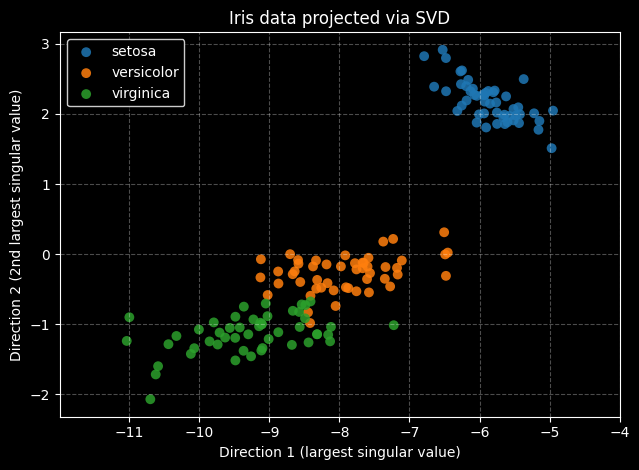

In [7]:
species = ['setosa', 'versicolor', 'virginica']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = load_iris().target  # 0,1,2

plt.style.use("dark_background")
plt.figure(dpi=100)

for i, sp in enumerate(species):
    mask = (labels == i)
    plt.scatter(Z[mask, 0], Z[mask, 1],
                c=colors[i], label=sp,
                alpha=0.85, edgecolor='none', s=50)

plt.xlabel("Direction 1 (largest singular value)")
plt.ylabel("Direction 2 (2nd largest singular value)")
plt.title("Iris data projected via SVD")
plt.legend(frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')
plt.axis('equal')
plt.tight_layout()
plt.show()

We can see that the three different classes of iris flowers cluster together really well. In particular, it’ll be really easy for us to differentiate Setosa from Versicolor or Virginica samples. 

Notice how **Setosa** forms a distinct, isolated group in the upper-right region, while Versicolor and Virginica overlap more closely in the lower-left/center. This separation confirms that our dimensionality reduction preserved the most critical structural differences between the species of iris flowers.

By discarding the last two dimensions which contributed less than 1% of the total variance/information, we effectively filtered out noise and simplified this dataset. This shows that the first two singular vectors $\mathbf{V}_k$ spanned the subspace where the data is most "spread out." The reduced $Z$ matrix captures nearly identical separability with far fewer parameters.

We can examine the different dimesnions (features) of this dataset to qualitatively view different dimensions of the raw dataset, and compare them to our more arbitrary reduced dimensions from the previous chart with the following.

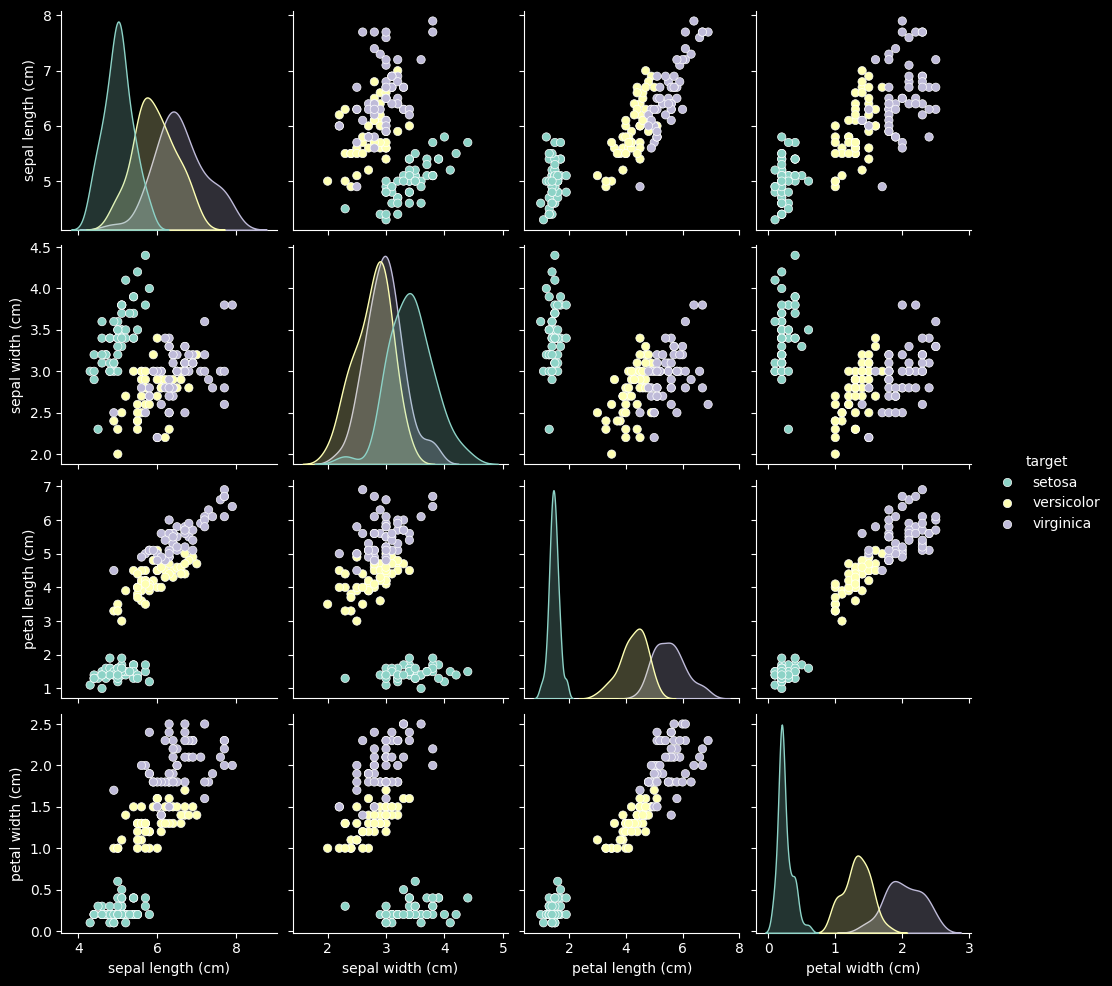

In [8]:
import seaborn as sns

iris = load_iris(as_frame=True)
iris.frame["target"] = iris.target_names[iris.target]
_ = sns.pairplot(iris.frame, hue="target")

We can see that the petal length and width dimensions have much more variation than the sepal features.

In comparing these physical features to the derived singular value directions from our previous chart, we notice they capture similar patterns. While we might intuitively select "petal length vs. width" because it looks best visually, this subjective choice lacks a rigorous justification without statistical or mathematical backing. Our $k=2$ dimensions chosen via dimensionality reduction are mathematically sound because they explicitly maximize the retained variance.

So in conclusion, dimensionality reduction is a very powerful technique, and what was shown here was just the linear algebra (via SVD) that is generally used in dimensionality reduction. In actial data science/analysis you will most likely use more specific technique, but the same general idea as what we just explored broadly apply to those techniques. See the dimensionality reduction  examples in the [sklearn user guide](https://scikit-learn.org/stable/user_guide.html) for more info on those more specific techniques.